In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

# Przygotowanie danych

### Pobranie danych

In [2]:
signal = np.loadtxt("assets/signal.csv")

### Wygenerowanie danych

In [2]:
import impuls_simulator
B=30
fs=25000
varsize=25000
fmod=30
f_center=6000
bandwidth=500
shift=0
sigma = 5
signal = impuls_simulator.gen_signal(B,fs,varsize,fmod,f_center,bandwidth,shift,sigma)

## Szereg w czasie

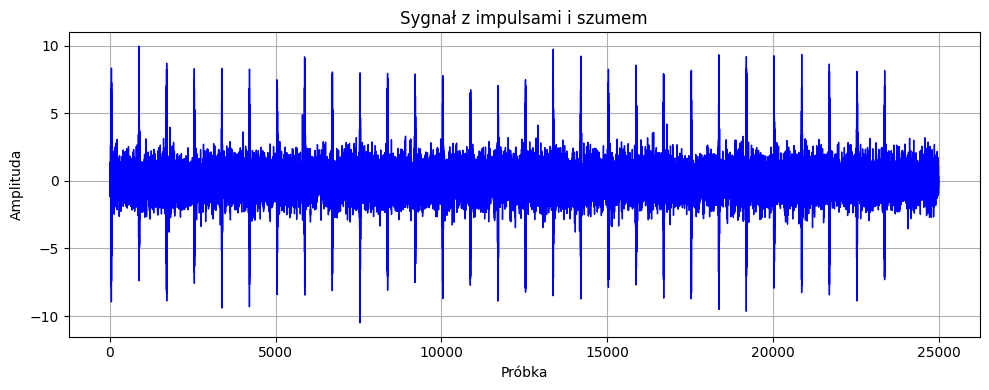

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(signal, color='blue', linewidth=1)
plt.title("Sygnał z impulsami i szumem")
plt.xlabel("Próbka")
plt.ylabel("Amplituda")
plt.grid(True)
plt.tight_layout()
plt.show()

## Spektrogram

### Obliczenie krótkoczasowej transformaty Fouriera

In [4]:
fs = 25000
array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal, fs = fs, window = 'hann')
Zxx = np.abs(matrix_Zxx)

### Wyrysowanie wykresu

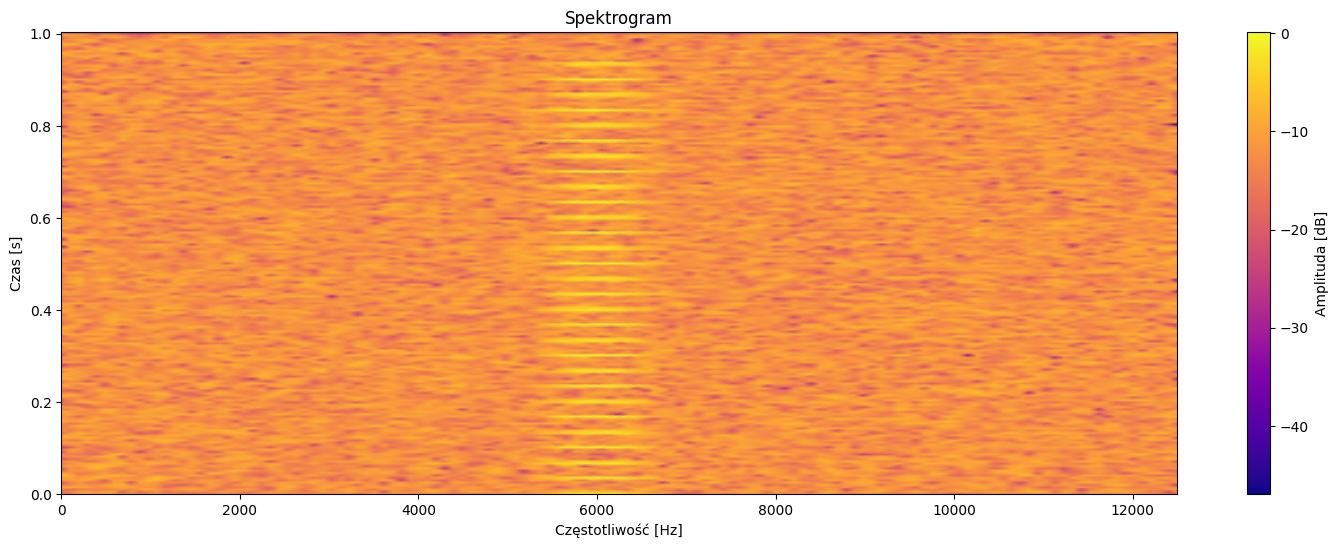

In [5]:

plt.figure(figsize=(18, 6))
plt.pcolormesh(array_freq, array_tt, 10*np.log10(Zxx.T), shading='gouraud', cmap='plasma')
plt.xlabel('Częstotliwość [Hz]')
plt.ylabel('Czas [s]')
plt.title('Spektrogram')
plt.colorbar(label='Amplituda [dB]')
plt.show()

# Selektory

In [6]:
import ifb_selectors as selector

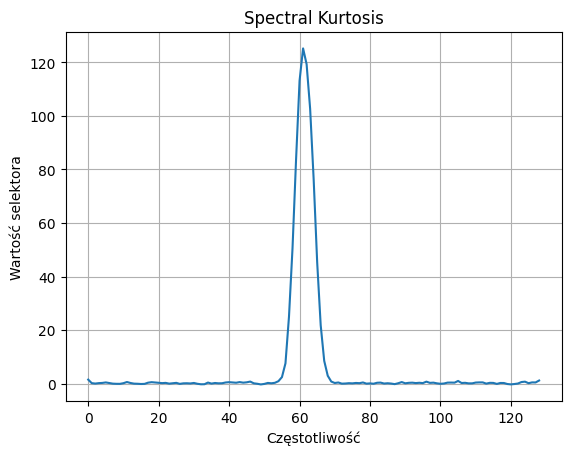

In [12]:
sk_results = selector.SK(Zxx)
fig, axes = plt.subplots()
axes.plot(sk_results)
axes.set_title("Spectral Kurtosis")
axes.set_xlabel("Częstotliwość")
axes.set_ylabel("Wartość selektora")
axes.grid()
plt.show()

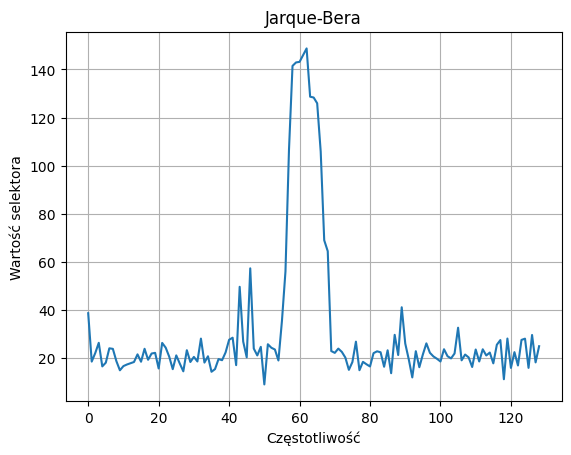

In [14]:
jb_results = selector.JB(Zxx)
fig, axes = plt.subplots()
axes.plot(jb_results)
axes.set_title("Jarque-Bera")
axes.set_xlabel("Częstotliwość")
axes.set_ylabel("Wartość selektora")
axes.grid()
plt.show()

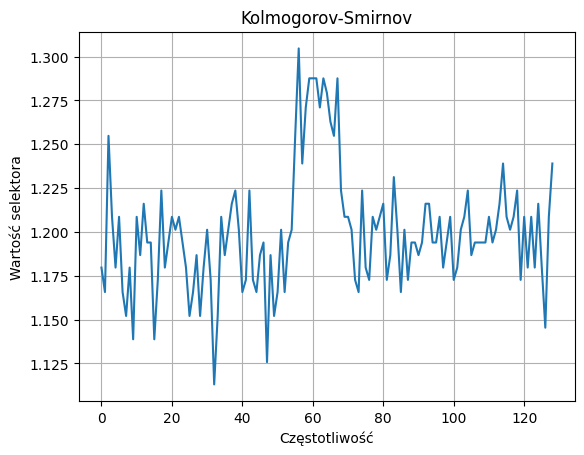

In [15]:
kss_results = selector.KSS(Zxx)
fig, axes = plt.subplots()
axes.plot(kss_results)
axes.set_title("Kolmogorov-Smirnov")
axes.set_xlabel("Częstotliwość")
axes.set_ylabel("Wartość selektora")
axes.grid()
plt.show()

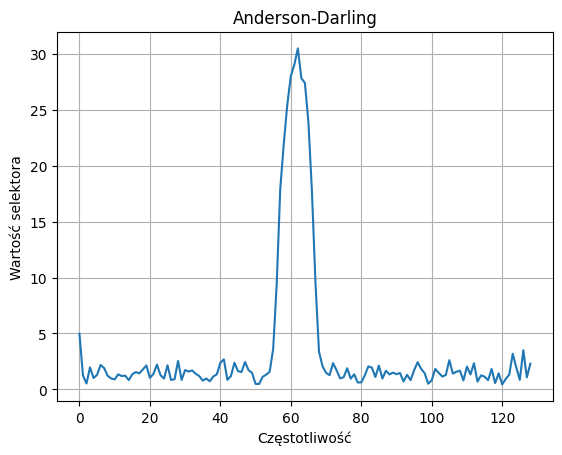

In [16]:
ad_results = selector.AD(Zxx)
fig, axes = plt.subplots()
axes.plot(ad_results)
axes.set_title("Anderson-Darling")
axes.set_xlabel("Częstotliwość")
axes.set_ylabel("Wartość selektora")
axes.grid()
plt.show()

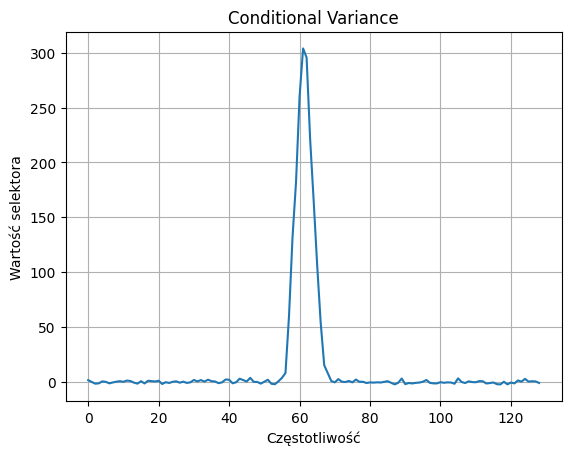

In [18]:
cvs_results = selector.cvs(Zxx)
fig, axes = plt.subplots()
axes.plot(cvs_results)
axes.set_title("Conditional Variance")
axes.set_xlabel("Częstotliwość")
axes.set_ylabel("Wartość selektora")
axes.grid()
plt.show()

## Faktyczne obliczenie wszystkich selektorów


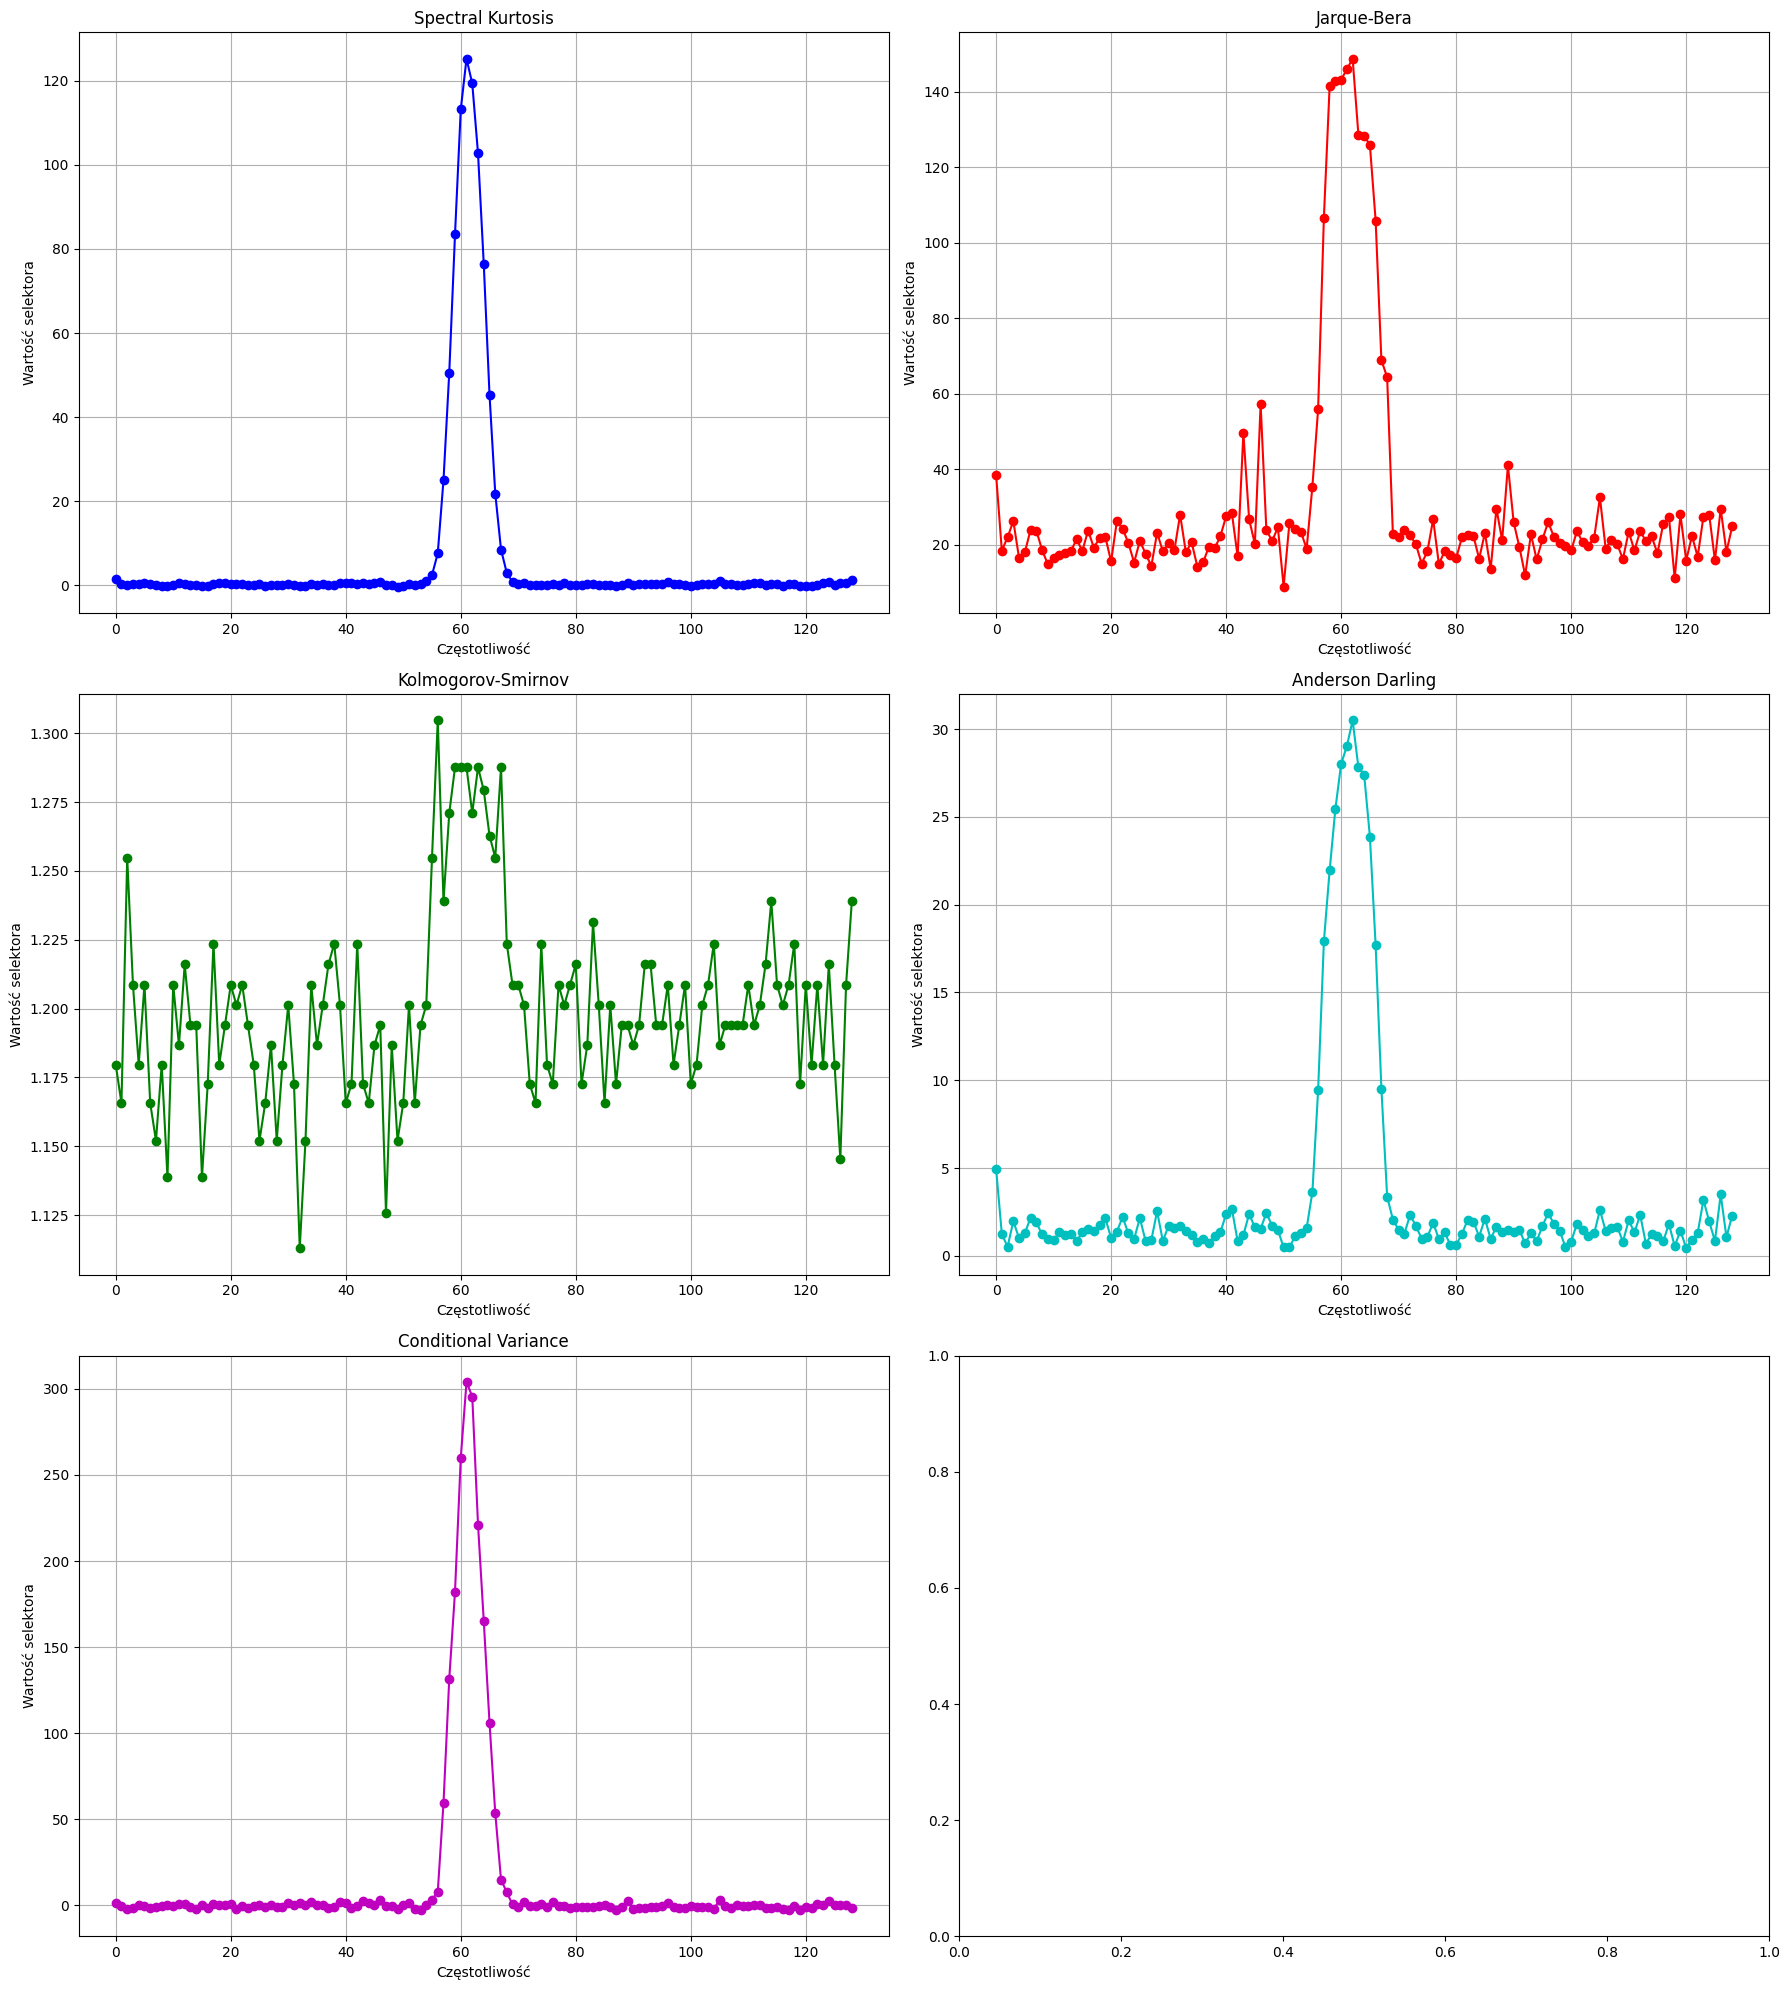

In [54]:
sk_results = selector.SK(Zxx)
jb_results = selector.JB(Zxx)
kss_results = selector.KSS(Zxx)
ad_results = selector.AD(Zxx)
cvs_results = selector.cvs(Zxx)

fig, axes = plt.subplots(3,2,figsize=(18,20))
axes[0,0].plot(sk_results,'bo-')
axes[0,0].set_title("Spectral Kurtosis")
axes[0,0].set_xlabel("Częstotliwość")
axes[0,0].set_ylabel("Wartość selektora")

axes[0,1].plot(jb_results,'ro-')
axes[0,1].set_title("Jarque-Bera")
axes[0,1].set_xlabel("Częstotliwość")
axes[0,1].set_ylabel("Wartość selektora")

axes[1,0].plot(kss_results,'go-')
axes[1,0].set_title("Kolmogorov-Smirnov")
axes[1,0].set_xlabel("Częstotliwość")
axes[1,0].set_ylabel("Wartość selektora")

axes[1,1].plot(ad_results,'co-')
axes[1,1].set_title("Anderson Darling")
axes[1,1].set_xlabel("Częstotliwość")
axes[1,1].set_ylabel("Wartość selektora")

axes[2,0].plot(cvs_results,'mo-')
axes[2,0].set_title("Conditional Variance")
axes[2,0].set_xlabel("Częstotliwość")
axes[2,0].set_ylabel("Wartość selektora")

axes[0,0].grid()
axes[0,1].grid()
axes[1,0].grid()
axes[1,1].grid()
axes[2,0].grid()

plt.tight_layout()
plt.show()